<a href="https://colab.research.google.com/github/Shazid2004/git-tutorial-exercise/blob/feature-1/Copy_of_smoker_dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Kaggle Imports

In [1]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
kukuroo3_body_signal_of_smoking_path = kagglehub.dataset_download('kukuroo3/body-signal-of-smoking')

print('Data source import complete.')


100%|██████████| 3.40M/3.40M [00:00<00:00, 74.6MB/s]

Extracting files...


Data source import complete.


In [2]:
kukuroo3_body_signal_of_smoking_path

'/root/.cache/kagglehub/datasets/kukuroo3/body-signal-of-smoking/versions/2'

In [3]:
!ls /root/.cache/kagglehub/datasets/kukuroo3/body-signal-of-smoking/versions/2

competition_format  smoking.csv


In [4]:
!ls /root/.cache/kagglehub/datasets/kukuroo3/body-signal-of-smoking/versions/2/competition_format

x_test.csv  x_train.csv  y_test.csv  y_train.csv


# Smoker Dataset Analysis & Detection Model

## Data Analysis

### Imports

In [5]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns

### Data Fetching & Basic Observation

In [6]:
X_train = pd.read_csv(kukuroo3_body_signal_of_smoking_path + '/competition_format/x_train.csv', index_col="ID")
X_test = pd.read_csv(kukuroo3_body_signal_of_smoking_path + '/competition_format/x_test.csv', index_col="ID")
y_train = pd.read_csv(kukuroo3_body_signal_of_smoking_path + '/competition_format/y_train.csv', index_col="ID")
y_test = pd.read_csv(kukuroo3_body_signal_of_smoking_path + '/competition_format/y_test.csv', index_col="ID")
df_train = pd.concat([X_train, y_train], axis=1, )
df_test = pd.concat([X_test, y_test], axis=1, )

In [7]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 44553 entries, 0 to 55690
Data columns (total 26 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   gender               44553 non-null  object 
 1   age                  44553 non-null  int64  
 2   height(cm)           44553 non-null  int64  
 3   weight(kg)           44553 non-null  int64  
 4   waist(cm)            44553 non-null  float64
 5   eyesight(left)       44553 non-null  float64
 6   eyesight(right)      44553 non-null  float64
 7   hearing(left)        44553 non-null  float64
 8   hearing(right)       44553 non-null  float64
 9   systolic             44553 non-null  float64
 10  relaxation           44553 non-null  float64
 11  fasting blood sugar  44553 non-null  float64
 12  Cholesterol          44553 non-null  float64
 13  triglyceride         44553 non-null  float64
 14  HDL                  44553 non-null  float64
 15  LDL                  44553 non-null  floa

In [8]:
df_train.describe()

,age,height(cm),weight(kg),waist(cm),eyesight(left),eyesight(right),hearing(left),hearing(right),systolic,relaxation,...,HDL,LDL,hemoglobin,Urine protein,serum creatinine,AST,ALT,Gtp,dental caries,smoking
count,44553.000000,44553.000000,44553.000000,44553.000000,44553.000000,44553.000000,44553.00000,44553.000000,44553.000000,44553.000000,...,44553.000000,44553.000000,44553.000000,44553.000000,44553.000000,44553.000000,44553.000000,44553.000000,44553.000000,44553.000000
mean,44.210603,164.657038,65.883442,82.077247,1.011734,1.008134,1.02561,1.026036,121.529055,76.043454,...,57.288421,115.037663,14.622194,1.087020,0.886097,26.213678,27.084731,40.065517,0.213521,0.367024
std,12.089077,9.198571,12.823676,9.278288,0.488131,0.488762,0.15797,0.159245,13.688748,9.695288,...,14.795235,40.937878,1.564872,0.404944,0.226092,19.087106,31.754805,50.723521,0.409797,0.481998
min,20.000000,130.000000,30.000000,51.000000,0.100000,0.100000,1.00000,1.000000,71.000000,40.000000,...,4.000000,1.000000,4.900000,1.000000,0.100000,6.000000,1.000000,1.000000,0.000000,0.000000
25%,40.000000,160.000000,55.000000,76.000000,0.800000,0.800000,1.00000,1.000000,112.000000,70.000000,...,47.000000,92.000000,13.600000,1.000000,0.800000,19.000000,15.000000,17.000000,0.000000,0.000000
50%,40.000000,165.000000,65.000000,82.000000,1.000000,1.000000,1.00000,1.000000,120.000000,76.000000,...,55.000000,113.000000,14.800000,1.000000,0.900000,23.000000,21.000000,26.000000,0.000000,0.000000
75%,55.000000,170.000000,75.000000,88.000000,1.200000,1.200000,1.00000,1.000000,130.000000,82.000000,...,66.000000,136.000000,15.700000,1.000000,1.000000,29.000000,31.000000,44.000000,0.000000,1.000000
max,85.000000,190.000000,135.000000,129.000000,9.900000,9.900000,2.00000,2.000000,240.000000,146.000000,...,618.000000,1860.000000,21.100000,6.000000,11.600000,1311.000000,2914.000000,999.000000,1.000000,1.000000


In [9]:
df_train.head()

,gender,age,height(cm),weight(kg),waist(cm),eyesight(left),eyesight(right),hearing(left),hearing(right),systolic,...,hemoglobin,Urine protein,serum creatinine,AST,ALT,Gtp,oral,dental caries,tartar,smoking
ID,,,,,,,,,,,,,,,,,,,,,
0,F,40,155,60,81.3,1.2,1.0,1.0,1.0,114.0,...,12.9,1.0,0.7,18.0,19.0,27.0,Y,0.0,Y,0
1,F,40,160,60,81.0,0.8,0.6,1.0,1.0,119.0,...,12.7,1.0,0.6,22.0,19.0,18.0,Y,0.0,Y,0
2,M,55,170,60,80.0,0.8,0.8,1.0,1.0,138.0,...,15.8,1.0,1.0,21.0,16.0,22.0,Y,0.0,N,1
3,M,40,165,70,88.0,1.5,1.5,1.0,1.0,100.0,...,14.7,1.0,1.0,19.0,26.0,18.0,Y,0.0,Y,0
4,F,40,155,60,86.0,1.0,1.0,1.0,1.0,120.0,...,12.5,1.0,0.6,16.0,14.0,22.0,Y,0.0,N,0


### Data Engineering

In [10]:
def feature_creation(df):
    df['BMI'] = df['weight(kg)'] / ((df['height(cm)'] / 100) ** 2)
    df['eyesight'] = (df['eyesight(left)'] + df['eyesight(right)']) / 2
    df['hearing'] = (df['hearing(left)'] + df['hearing(right)']) / 2
    df['pulse'] = (df['systolic'] - df['relaxation'])
    df[df.columns[df.dtypes == 'int64']] = df[df.columns[df.dtypes == 'int64']].astype('float64')
    return df

In [11]:
df_train = feature_creation(df_train)
df_test = feature_creation(df_test)

In [13]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 44553 entries, 0 to 55690
Data columns (total 30 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   gender               44553 non-null  object 
 1   age                  44553 non-null  float64
 2   height(cm)           44553 non-null  float64
 3   weight(kg)           44553 non-null  float64
 4   waist(cm)            44553 non-null  float64
 5   eyesight(left)       44553 non-null  float64
 6   eyesight(right)      44553 non-null  float64
 7   hearing(left)        44553 non-null  float64
 8   hearing(right)       44553 non-null  float64
 9   systolic             44553 non-null  float64
 10  relaxation           44553 non-null  float64
 11  fasting blood sugar  44553 non-null  float64
 12  Cholesterol          44553 non-null  float64
 13  triglyceride         44553 non-null  float64
 14  HDL                  44553 non-null  float64
 15  LDL                  44553 non-null  floa

### Special Observation

In [14]:
df_train[['age', 'weight(kg)', 'smoking']].groupby(['age', 'smoking']).describe()

weight(kg)                                                     
                  count       mean        std   min   25%   50%   75%    max
age  smoking                                                                
20.0 0.0          631.0  71.315372  12.124241  45.0  65.0  70.0  80.0  130.0
     1.0          662.0  70.868580  11.447807  45.0  65.0  70.0  80.0  110.0
25.0 0.0         1512.0  72.615741  11.834669  40.0  65.0  70.0  80.0  120.0
     1.0         1300.0  73.834615  12.803947  45.0  65.0  70.0  80.0  130.0
30.0 0.0         1691.0  74.444116  11.675531  45.0  65.0  75.0  80.0  130.0
     1.0         1529.0  75.264879  12.746720  45.0  65.0  75.0  80.0  135.0
35.0 0.0         1705.0  74.859238  11.303439  45.0  65.0  75.0  80.0  120.0
     1.0         1900.0  74.976316  12.094370  45.0  65.0  75.0  85.0  120.0
40.0 0.0         7609.0  61.178210  12.241343  35.0  50.0  60.0  70.0  120.0
     1.0         4471.0  72.128159  12.107143  40.0  65.0  70.0  80.0  125.0
45.0 0.0         3750.0  60.216000  11.160640  35.0  50.0  60.0  65.0  110.0
     1.0         1904.0  69.942227  10.803107  35.0  65.0  70.0  75.0  125.0
50.0 0.0         2921.0  60.164327  10.585127  30.0  50.0  60.0  65.0  110.0
     1.0         1506.0  68.396414  10.571771  35.0  60.0  70.0  75.0  115.0
55.0 0.0         2858.0  59.622113  10.045258  35.0  50.0  60.0  65.0  105.0
     1.0         1200.0  66.541667   9.793443  35.0  60.0  65.0  70.0  100.0
60.0 0.0         3540.0  59.871469   9.920089  30.0  55.0  60.0  65.0  105.0
     1.0         1390.0  64.928058   9.947407  40.0  60.0  65.0  70.0  100.0
65.0 0.0          830.0  59.831325   9.128250  40.0  55.0  60.0  65.0   90.0
     1.0          243.0  63.395062   9.775174  40.0  55.0  65.0  70.0   90.0
70.0 0.0          524.0  59.437023   9.455433  40.0  55.0  60.0  65.0   85.0
     1.0          137.0  62.518248   8.620344  40.0  60.0  65.0  70.0   85.0
75.0 0.0          412.0  59.223301   8.830859  30.0  55.0  60.0  65.0   85.0
     1.0           83.0  61.686747   9.115690  45.0  55.0  60.0  65.0   90.0
80.0 0.0          205.0  57.682927   9.067933  30.0  50.0  55.0  65.0   80.0
     1.0           26.0  55.576923   7.526875  40.0  50.0  55.0  60.0   70.0
85.0 0.0           13.0  59.615385  10.299988  40.0  50.0  60.0  70.0   70.0
     1.0            1.0  55.000000        NaN  55.0  55.0  55.0  55.0   55.0

In [15]:
df_train[['age', 'waist(cm)', 'smoking']].groupby(['age', 'smoking']).describe()

waist(cm)                                                        
                 count       mean       std   min     25%   50%     75%    max
age  smoking                                                                  
20.0 0.0         631.0  80.987322  8.793493  63.0  75.000  80.0  85.000  128.0
     1.0         662.0  80.801813  8.532978  61.0  75.000  80.0  86.075  111.5
25.0 0.0        1512.0  83.113360  8.645386  62.0  77.000  82.0  88.000  118.5
     1.0        1300.0  84.185615  9.400037  61.0  78.000  83.0  89.000  127.0
30.0 0.0        1691.0  85.062921  8.555199  58.0  79.000  84.4  90.000  121.0
     1.0        1529.0  85.640026  9.071499  60.0  79.000  85.0  91.000  129.0
35.0 0.0        1705.0  85.719531  8.208261  64.0  80.000  85.0  91.000  118.2
     1.0        1900.0  85.948368  8.814164  61.5  80.000  85.2  91.600  125.8
40.0 0.0        7609.0  77.962557  9.594377  54.0  71.000  77.0  84.300  127.7
     1.0        4471.0  85.039767  8.938197  54.0  79.000  85.0  90.550  124.0
45.0 0.0        3750.0  78.306213  9.098506  56.0  72.000  78.0  84.000  115.0
     1.0        1904.0  84.757300  8.392361  57.2  79.475  84.5  90.000  124.0
50.0 0.0        2921.0  79.380178  8.652056  56.0  73.000  79.0  85.000  117.0
     1.0        1506.0  84.676627  8.186114  51.0  79.000  84.9  90.000  116.0
55.0 0.0        2858.0  79.944892  8.483654  55.0  74.000  79.5  85.500  118.0
     1.0        1200.0  84.313750  7.778470  61.0  79.000  84.0  89.000  113.0
60.0 0.0        3540.0  81.781412  8.351161  53.0  76.000  81.6  87.000  115.6
     1.0        1390.0  84.676043  8.071506  60.0  79.800  85.0  90.000  110.0
65.0 0.0         830.0  83.484096  7.875844  61.5  78.000  83.5  89.000  112.0
     1.0         243.0  85.004527  7.795428  66.0  80.000  85.0  90.000  108.5
70.0 0.0         524.0  83.851527  8.449819  62.0  78.075  84.0  89.500  111.0
     1.0         137.0  85.583942  7.475433  65.2  81.000  85.4  90.200  102.0
75.0 0.0         412.0  84.110680  8.172420  56.0  79.000  84.3  89.775  108.0
     1.0          83.0  85.585542  8.482955  65.0  80.000  86.5  90.000  105.6
80.0 0.0         205.0  85.062439  8.437051  58.0  79.000  85.4  90.000  111.0
     1.0          26.0  81.630769  5.995116  64.0  79.050  82.5  84.750   91.0
85.0 0.0          13.0  86.030769  6.957296  72.0  83.000  84.5  92.900   95.0
     1.0           1.0  86.000000       NaN  86.0  86.000  86.0  86.000   86.0

In [16]:
df_train[['age', 'BMI', 'smoking']].groupby(['age', 'smoking']).describe()

BMI                                                        \
               count       mean       std        min        25%        50%   
age  smoking                                                                 
20.0 0.0       631.0  24.182008  3.593284  16.975309  21.913806  23.875115   
     1.0       662.0  23.909180  3.487790  15.570934  21.484375  23.875115   
25.0 0.0      1512.0  24.466534  3.557733  16.326531  22.038567  24.221453   
     1.0      1300.0  24.795618  3.893133  16.326531  22.038567  24.221453   
30.0 0.0      1691.0  25.054586  3.498115  16.528926  22.491349  24.489796   
     1.0      1529.0  25.241887  3.846445  16.326531  22.491349  24.489796   
35.0 0.0      1705.0  25.201253  3.377950  15.570934  22.857143  24.489796   
     1.0      1900.0  25.212730  3.669666  15.570934  22.491349  24.691358   
40.0 0.0      7609.0  23.274419  3.621430  15.555556  20.811655  22.892820   
     1.0      4471.0  24.910465  3.585542  15.570934  22.491349  24.489796   
45.0 0.0      3750.0  23.485609  3.372202  14.568158  20.811655  22.892820   
     1.0      1904.0  24.532888  3.245475  14.692378  22.491349  24.221453   
50.0 0.0      2921.0  23.820464  3.257869  14.568158  21.484375  23.437500   
     1.0      1506.0  24.440719  3.288737  15.555556  22.038567  24.221453   
55.0 0.0      2858.0  23.761485  3.044199  15.555556  21.484375  23.437500   
     1.0      1200.0  24.041131  3.048478  15.570934  22.038567  23.875115   
60.0 0.0      3540.0  24.175020  3.131515  14.268728  22.222222  23.875115   
     1.0      1390.0  23.921187  3.199648  14.692378  21.484375  23.875115   
65.0 0.0       830.0  24.317524  2.923416  16.649324  22.222222  24.221453   
     1.0       243.0  23.583665  3.057857  15.625000  21.484375  23.437500   
70.0 0.0       524.0  24.297842  3.077965  16.649324  22.222222  24.444444   
     1.0       137.0  23.742077  2.789932  17.578125  22.038567  23.875115   
75.0 0.0       412.0  23.917810  2.956678  14.268728  22.038567  23.875115   
     1.0        83.0  23.253107  2.875826  16.528926  21.354432  23.437500   
80.0 0.0       205.0  23.838788  2.885924  14.268728  22.038567  23.781213   
     1.0        26.0  21.966117  2.562585  15.625000  20.811655  22.130395   
85.0 0.0        13.0  23.446935  2.396815  18.730489  22.222222  23.781213   
     1.0         1.0  22.892820       NaN  22.892820  22.892820  22.892820   

                                    
                    75%        max  
age  smoking                        
20.0 0.0      26.037003  42.448980  
     1.0      25.951557  35.918367  
25.0 0.0      26.122449  39.183673  
     1.0      27.548209  40.816327  
30.0 0.0      27.548209  42.448980  
     1.0      27.681661  41.666667  
35.0 0.0      27.548209  39.183673  
     1.0      27.681661  39.183673  
40.0 0.0      25.390625  41.015625  
     1.0      27.548209  40.816327  
45.0 0.0      25.390625  39.062500  
     1.0      26.122449  40.816327  
50.0 0.0      25.711662  41.623309  
     1.0      25.951557  38.567493  
55.0 0.0      25.711662  37.109375  
     1.0      25.951557  34.894399  
60.0 0.0      26.122449  38.567493  
     1.0      25.711662  36.730946  
65.0 0.0      26.159334  35.555556  
     1.0      25.711662  31.250000  
70.0 0.0      26.159334  33.333333  
     1.0      25.711662  31.217482  
75.0 0.0      25.711662  33.293698  
     1.0      25.390625  31.141869  
80.0 0.0      25.711662  31.250000  
     1.0      23.695285  25.711662  
85.0 0.0      25.390625  25.711662  
     1.0      22.892820  22.892820

In [17]:
df_train[['age', 'eyesight', 'smoking']].groupby(['age', 'smoking']).describe()

eyesight                                                  
                count      mean       std   min   25%   50%   75%   max
age  smoking                                                           
20.0 0.0        631.0  1.145642  0.428110  0.10  0.95  1.10  1.35  5.70
     1.0        662.0  1.098716  0.316207  0.10  0.90  1.10  1.35  2.00
25.0 0.0       1512.0  1.106944  0.325145  0.10  0.95  1.10  1.35  5.70
     1.0       1300.0  1.078731  0.339921  0.10  0.90  1.10  1.35  5.25
30.0 0.0       1691.0  1.130367  0.333489  0.10  0.95  1.10  1.35  5.70
     1.0       1529.0  1.108077  0.299779  0.10  0.90  1.10  1.35  2.00
35.0 0.0       1705.0  1.130880  0.329779  0.20  1.00  1.10  1.35  5.70
     1.0       1900.0  1.128684  0.321866  0.10  0.95  1.10  1.35  5.70
40.0 0.0       7609.0  1.054041  0.333006  0.10  0.90  1.05  1.20  9.90
     1.0       4471.0  1.096567  0.326521  0.10  0.95  1.10  1.25  5.70
45.0 0.0       3750.0  0.971293  0.373876  0.10  0.80  1.00  1.10  9.90
     1.0       1904.0  1.025131  0.332268  0.10  0.85  1.00  1.20  5.95
50.0 0.0       2921.0  0.944728  0.382934  0.10  0.75  0.95  1.10  9.90
     1.0       1506.0  1.011189  0.380054  0.20  0.85  1.00  1.20  5.70
55.0 0.0       2858.0  0.931176  0.437930  0.10  0.75  0.90  1.10  9.90
     1.0       1200.0  0.979542  0.510188  0.25  0.80  0.95  1.10  9.90
60.0 0.0       3540.0  0.853093  0.445949  0.10  0.65  0.85  1.00  9.90
     1.0       1390.0  0.878777  0.445414  0.10  0.70  0.85  1.00  5.70
65.0 0.0        830.0  0.807831  0.615706  0.10  0.60  0.75  0.90  9.90
     1.0        243.0  0.869959  0.851883  0.10  0.60  0.75  0.95  9.90
70.0 0.0        524.0  0.740076  0.511742  0.10  0.50  0.70  0.85  5.45
     1.0        137.0  0.873358  1.054769  0.20  0.55  0.75  0.90  9.90
75.0 0.0        412.0  0.731675  0.637712  0.10  0.50  0.65  0.80  5.70
     1.0         83.0  0.757831  0.759954  0.10  0.45  0.65  0.80  5.30
80.0 0.0        205.0  0.662683  0.591119  0.10  0.45  0.60  0.75  5.25
     1.0         26.0  0.607692  0.194264  0.20  0.45  0.60  0.75  0.90
85.0 0.0         13.0  0.553846  0.260977  0.20  0.35  0.55  0.70  1.05
     1.0          1.0  0.650000       NaN  0.65  0.65  0.65  0.65  0.65

In [18]:
df_train[['age', 'systolic', 'smoking']].groupby(['age', 'smoking']).describe()

systolic                                                       \
                count        mean        std    min     25%    50%     75%   
age  smoking                                                                 
20.0 0.0        631.0  119.269414  10.801984   90.0  110.00  119.0  126.00   
     1.0        662.0  119.802115  11.141171   90.0  110.00  120.0  128.00   
25.0 0.0       1512.0  121.365079  11.588593   90.0  114.00  120.0  130.00   
     1.0       1300.0  121.053077  11.860861   82.0  112.00  120.0  130.00   
30.0 0.0       1691.0  121.523359  11.569441   85.0  114.00  120.0  130.00   
     1.0       1529.0  121.958143  11.764023   90.0  114.00  120.0  130.00   
35.0 0.0       1705.0  122.089736  11.546377   87.0  114.00  120.0  130.00   
     1.0       1900.0  122.697895  12.167486   81.0  114.00  122.0  130.00   
40.0 0.0       7609.0  116.904587  13.423219   72.0  108.00  117.0  126.00   
     1.0       4471.0  122.502572  13.505801   81.0  114.00  121.0  130.00   
45.0 0.0       3750.0  118.873333  14.144897   80.0  110.00  118.0  128.00   
     1.0       1904.0  122.721639  13.384379   83.0  114.00  122.0  130.00   
50.0 0.0       2921.0  120.429647  13.854303   86.0  110.00  120.0  130.00   
     1.0       1506.0  122.914343  13.282716   86.0  114.00  122.0  131.00   
55.0 0.0       2858.0  121.361442  14.085489   81.0  111.00  120.0  130.00   
     1.0       1200.0  124.172500  13.956721   84.0  115.00  124.0  133.00   
60.0 0.0       3540.0  124.957345  14.579987   81.0  116.00  124.0  134.00   
     1.0       1390.0  125.317986  13.758470   82.0  117.00  125.0  134.00   
65.0 0.0        830.0  127.915663  13.368585   90.0  119.00  129.0  136.00   
     1.0        243.0  127.415638  14.429226   71.0  118.00  128.0  137.00   
70.0 0.0        524.0  128.641221  14.700877   74.0  120.00  130.0  138.00   
     1.0        137.0  129.131387  15.899416   84.0  120.00  130.0  137.00   
75.0 0.0        412.0  131.254854  14.444814   90.0  121.00  130.0  140.00   
     1.0         83.0  130.180723  12.831121  103.0  120.00  130.0  138.50   
80.0 0.0        205.0  134.434146  15.740600   90.0  126.00  134.0  144.00   
     1.0         26.0  128.269231  15.175131  111.0  119.25  121.5  133.75   
85.0 0.0         13.0  129.692308   8.863639  110.0  124.00  130.0  135.00   
     1.0          1.0  135.000000        NaN  135.0  135.00  135.0  135.00   

                     
                max  
age  smoking         
20.0 0.0      174.0  
     1.0      152.0  
25.0 0.0      162.0  
     1.0      172.0  
30.0 0.0      180.0  
     1.0      190.0  
35.0 0.0      176.0  
     1.0      204.0  
40.0 0.0      240.0  
     1.0      233.0  
45.0 0.0      204.0  
     1.0      197.0  
50.0 0.0      181.0  
     1.0      180.0  
55.0 0.0      192.0  
     1.0      200.0  
60.0 0.0      198.0  
     1.0      189.0  
65.0 0.0      199.0  
     1.0      169.0  
70.0 0.0      179.0  
     1.0      196.0  
75.0 0.0      200.0  
     1.0      158.0  
80.0 0.0      178.0  
     1.0      164.0  
85.0 0.0      141.0  
     1.0      135.0

In [19]:
df_train[['age', 'relaxation', 'smoking']].groupby(['age', 'smoking']).describe()

relaxation                                                       
                  count       mean        std   min    25%   50%    75%    max
age  smoking                                                                  
20.0 0.0          631.0  73.307448   8.081564  51.0  68.00  72.0  80.00  103.0
     1.0          662.0  73.874622   8.087325  50.0  70.00  74.0  80.00  101.0
25.0 0.0         1512.0  74.639550   8.728061  48.0  70.00  75.0  80.00  110.0
     1.0         1300.0  75.017692   8.391526  51.0  70.00  75.0  80.00  122.0
30.0 0.0         1691.0  75.840923   8.789996  51.0  70.00  76.0  81.00  120.0
     1.0         1529.0  76.481360   8.937967  51.0  70.00  76.0  82.00  128.0
35.0 0.0         1705.0  76.606452   9.124817  50.0  70.00  76.0  82.00  122.0
     1.0         1900.0  77.771579   9.372376  51.0  70.00  78.0  83.00  146.0
40.0 0.0         7609.0  73.758707   9.973170  42.0  67.00  73.0  80.00  140.0
     1.0         4471.0  78.125252   9.922675  46.0  71.00  78.0  84.00  146.0
45.0 0.0         3750.0  74.885600  10.000933  40.0  68.00  75.0  80.00  130.0
     1.0         1904.0  78.474265   9.796101  55.0  71.00  79.0  85.00  132.0
50.0 0.0         2921.0  75.740157   9.861433  48.0  69.00  76.0  82.00  120.0
     1.0         1506.0  78.083001   9.603869  48.0  70.00  79.0  84.00  110.0
55.0 0.0         2858.0  75.824003   9.668616  50.0  70.00  76.0  82.00  129.0
     1.0         1200.0  78.305000   9.558143  51.0  71.75  79.0  84.00  130.0
60.0 0.0         3540.0  76.922599   9.654132  47.0  70.00  77.0  83.00  116.0
     1.0         1390.0  77.159712   9.115630  53.0  70.00  78.0  82.00  114.0
65.0 0.0          830.0  77.156627   9.198104  47.0  70.00  78.0  82.00  133.0
     1.0          243.0  76.316872   9.536489  50.0  70.00  77.0  81.00  115.0
70.0 0.0          524.0  75.946565   9.897226  40.0  70.00  76.0  82.00  117.0
     1.0          137.0  76.357664   9.730741  53.0  70.00  76.0  82.00  105.0
75.0 0.0          412.0  76.538835   9.722723  49.0  70.00  76.0  82.00  137.0
     1.0           83.0  75.000000   8.937452  59.0  69.00  74.0  80.50   93.0
80.0 0.0          205.0  75.487805   9.553569  50.0  69.00  76.0  80.00  102.0
     1.0           26.0  73.038462   9.597836  60.0  67.25  71.5  79.75   96.0
85.0 0.0           13.0  76.230769   8.378085  60.0  70.00  80.0  80.00   88.0
     1.0            1.0  68.000000        NaN  68.0  68.00  68.0  68.00   68.0

In [20]:
df_train[['age', 'pulse', 'smoking']].groupby(['age', 'smoking']).describe()

pulse                                                      
               count       mean        std   min   25%   50%    75%    max
age  smoking                                                              
20.0 0.0       631.0  45.961965   8.051529  27.0  40.0  45.0  50.00   79.0
     1.0       662.0  45.927492   8.264585  25.0  40.0  45.0  50.00   74.0
25.0 0.0      1512.0  46.725529   8.267176  17.0  40.0  46.0  52.00   90.0
     1.0      1300.0  46.035385   8.313450  22.0  40.0  45.5  51.00   79.0
30.0 0.0      1691.0  45.682436   7.844588  20.0  40.0  45.0  50.00   80.0
     1.0      1529.0  45.476782   7.906250  16.0  40.0  45.0  50.00   73.0
35.0 0.0      1705.0  45.483284   7.757163  21.0  40.0  45.0  50.00   73.0
     1.0      1900.0  44.926316   7.820918  19.0  40.0  44.0  50.00   97.0
40.0 0.0      7609.0  43.145880   8.073858  15.0  38.0  42.0  48.00  100.0
     1.0      4471.0  44.377321   8.361605  17.0  40.0  44.0  50.00  117.0
45.0 0.0      3750.0  43.987733   8.552529  16.0  39.0  43.0  50.00   90.0
     1.0      1904.0  44.247374   8.251514  20.0  39.0  44.0  50.00   90.0
50.0 0.0      2921.0  44.689490   8.435317  15.0  40.0  44.0  50.00   84.0
     1.0      1506.0  44.831341   8.446555  20.0  40.0  44.0  50.00   76.0
55.0 0.0      2858.0  45.537439   8.892751  19.0  40.0  45.0  51.00   85.0
     1.0      1200.0  45.867500   8.932605  19.0  40.0  46.0  50.25   85.0
60.0 0.0      3540.0  48.034746   9.742847  19.0  41.0  48.0  54.00   95.0
     1.0      1390.0  48.158273   9.647688  18.0  41.0  48.0  54.00  103.0
65.0 0.0       830.0  50.759036   9.838246  26.0  44.0  50.0  57.00   93.0
     1.0       243.0  51.098765  10.473822  10.0  45.0  51.0  58.50   87.0
70.0 0.0       524.0  52.694656  10.811539  14.0  46.0  52.5  59.00   88.0
     1.0       137.0  52.773723  10.650181  30.0  46.0  52.0  60.00   91.0
75.0 0.0       412.0  54.716019  10.792871  23.0  48.0  54.0  62.00   93.0
     1.0        83.0  55.180723  10.564719  30.0  48.0  53.0  64.00   77.0
80.0 0.0       205.0  58.946341  12.633291  24.0  50.0  58.0  67.00   94.0
     1.0        26.0  55.230769  10.327856  40.0  48.5  54.0  59.75   79.0
85.0 0.0        13.0  53.461538   8.903327  40.0  50.0  53.0  56.00   74.0
     1.0         1.0  67.000000        NaN  67.0  67.0  67.0  67.00   67.0

#### Conclusion
Appearently the Difference between smoker & non-smoker is more noticable in the age range of 35-60. Probably because there is not enough noticable harm done in the younger days and there are many other factors other than smoking causing harm in the elderly. Thus this model might not be conclusive out of this age range.

### Plottings

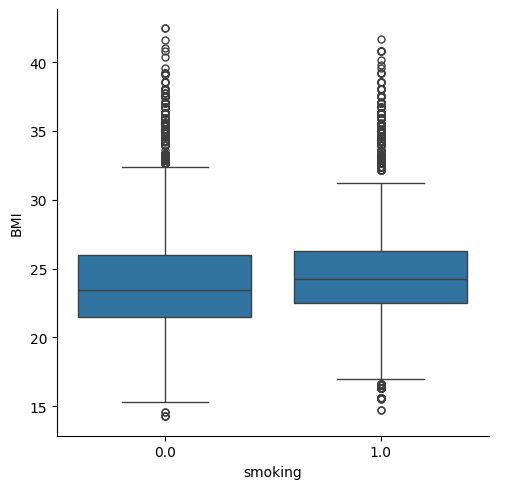

In [21]:
sns.catplot(data=df_train, x='smoking', y='BMI',kind='box')

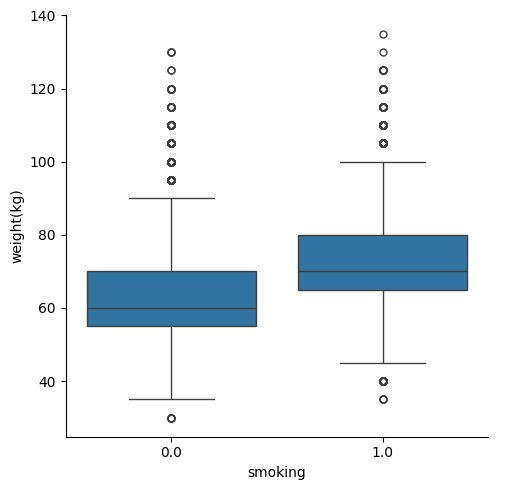

In [22]:
sns.catplot(data=df_train, x='smoking', y='weight(kg)',kind='box')

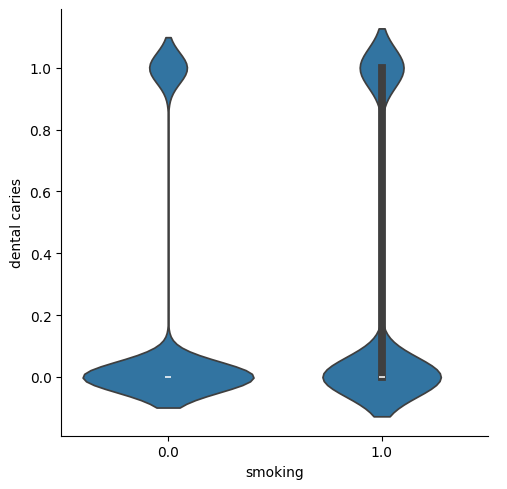

In [23]:
sns.catplot(data=df_train, x='smoking', y='dental caries',kind='violin')

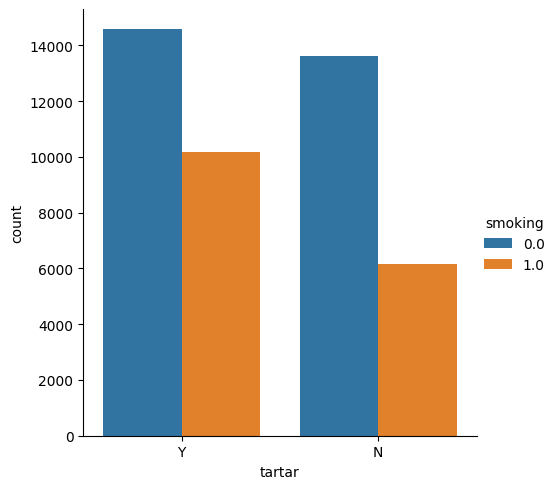

In [24]:
sns.catplot(data=df_train, x='tartar', hue='smoking', kind='count')

### Finding Outliers

In [25]:
def remove_outliers_idx(sr):
    min = sr.mean() - 3 * sr.std()
    max = sr.mean() + 3 * sr.std()

    return ((sr >= min) & (sr <= max))

In [26]:
df_train.columns[df_train.dtypes == 'float64']

Index(['age', 'height(cm)', 'weight(kg)', 'waist(cm)', 'eyesight(left)',
       'eyesight(right)', 'hearing(left)', 'hearing(right)', 'systolic',
       'relaxation', 'fasting blood sugar', 'Cholesterol', 'triglyceride',
       'HDL', 'LDL', 'hemoglobin', 'Urine protein', 'serum creatinine', 'AST',
       'ALT', 'Gtp', 'dental caries', 'smoking', 'BMI', 'eyesight', 'hearing',
       'pulse'],
      dtype='object')

In [27]:
over_ind = pd.Series(data=np.full(len(df_train), True), index=df_train.index)
for col in df_train.columns[df_train.dtypes == 'float64']:
    over_ind = over_ind & remove_outliers_idx(df_train[col])

In [28]:
df_train[over_ind]

,gender,age,height(cm),weight(kg),waist(cm),eyesight(left),eyesight(right),hearing(left),hearing(right),systolic,...,ALT,Gtp,oral,dental caries,tartar,smoking,BMI,eyesight,hearing,pulse
ID,,,,,,,,,,,,,,,,,,,,,
0,F,40.0,155.0,60.0,81.3,1.2,1.0,1.0,1.0,114.0,...,19.0,27.0,Y,0.0,Y,0.0,24.973985,1.10,1.0,41.0
1,F,40.0,160.0,60.0,81.0,0.8,0.6,1.0,1.0,119.0,...,19.0,18.0,Y,0.0,Y,0.0,23.437500,0.70,1.0,49.0
2,M,55.0,170.0,60.0,80.0,0.8,0.8,1.0,1.0,138.0,...,16.0,22.0,Y,0.0,N,1.0,20.761246,0.80,1.0,52.0
4,F,40.0,155.0,60.0,86.0,1.0,1.0,1.0,1.0,120.0,...,14.0,22.0,Y,0.0,N,0.0,24.973985,1.00,1.0,46.0
5,M,30.0,180.0,75.0,85.0,1.2,1.2,1.0,1.0,128.0,...,27.0,33.0,Y,0.0,Y,0.0,23.148148,1.20,1.0,52.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
55686,M,50.0,170.0,65.0,88.0,1.2,1.2,1.0,1.0,148.0,...,49.0,51.0,Y,0.0,Y,0.0,22.491349,1.20,1.0,54.0
55687,M,35.0,175.0,70.0,84.0,0.6,0.7,1.0,1.0,105.0,...,14.0,16.0,Y,0.0,Y,0.0,22.857143,0.65,1.0,31.0
55688,M,35.0,175.0,70.0,70.9,1.5,1.5,1.0,1.0,116.0,...,19.0,10.0,Y,0.0,Y,0.0,22.857143,1.50,1.0,46.0


In [29]:
d = [[], [], []]
d[0] = df_train.columns[df_train.dtypes == 'float64']
for i in d[0]:
    d[1].append(((len(df_train) - sum(remove_outliers_idx(df_train[i]))) / len(df_train)) * 100)
    d[2].append(((len(df_train[over_ind]) - sum(remove_outliers_idx(df_train[over_ind][i]))) / len(df_train[over_ind])) * 100)


In [30]:
r = pd.DataFrame(d, index=['Column', 'before', 'after']).T
r = r.set_index('Column')
r

,before,after
Column,,
age,0.031423,0.269984
height(cm),0.013467,0.0
weight(kg),0.724979,0.0
waist(cm),0.460126,0.074113
eyesight(left),0.166094,0.770249
eyesight(right),0.168339,0.706723
hearing(left),2.560995,0.0
hearing(right),2.603641,0.0
systolic,0.612753,0.246162


In [31]:
df_train[over_ind].info()

<class 'pandas.core.frame.DataFrame'>
Index: 37780 entries, 0 to 55690
Data columns (total 30 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   gender               37780 non-null  object 
 1   age                  37780 non-null  float64
 2   height(cm)           37780 non-null  float64
 3   weight(kg)           37780 non-null  float64
 4   waist(cm)            37780 non-null  float64
 5   eyesight(left)       37780 non-null  float64
 6   eyesight(right)      37780 non-null  float64
 7   hearing(left)        37780 non-null  float64
 8   hearing(right)       37780 non-null  float64
 9   systolic             37780 non-null  float64
 10  relaxation           37780 non-null  float64
 11  fasting blood sugar  37780 non-null  float64
 12  Cholesterol          37780 non-null  float64
 13  triglyceride         37780 non-null  float64
 14  HDL                  37780 non-null  float64
 15  LDL                  37780 non-null  floa

### Final Data Engineering

In [32]:
df_train['age']

,age
ID,
0,40.0
1,40.0
2,55.0
3,40.0
4,40.0
...,...
55686,50.0
55687,35.0
55688,35.0


In [33]:
type((df_train['hearing(left)'] - df_train['hearing(left)'].min()) / (df_train['hearing(left)'].max() - df_train['hearing(left)'].min()))

pandas.core.series.Series

In [34]:
def data_engineering(df):
    df = df.copy()
    df['gender'] = df['gender'].replace({'F': '0.0', 'M': '1.0'}).astype('float64')
    df['tartar'] = df['tartar'].replace({'Y': '1.0', 'N': '0.0'}).astype('float64')
    df['oral'] = df['oral'].replace({'Y': '1.0', 'N': '0.0'}).astype('float64')
    for col in df.columns[df.dtypes == 'float64']:
        if len(df[col].value_counts()) > 1:
            df[col] = ((df[col] - df[col].min()) / (df[col].max() - df[col].min()))
    return df

In [35]:
ovr_df_train = df_train[over_ind]

In [38]:
final_df_train = data_engineering(ovr_df_train)
final_df_test = data_engineering(df_test)

In [40]:
final_df_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 37780 entries, 0 to 55690
Data columns (total 30 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   gender               37780 non-null  float64
 1   age                  37780 non-null  float64
 2   height(cm)           37780 non-null  float64
 3   weight(kg)           37780 non-null  float64
 4   waist(cm)            37780 non-null  float64
 5   eyesight(left)       37780 non-null  float64
 6   eyesight(right)      37780 non-null  float64
 7   hearing(left)        37780 non-null  float64
 8   hearing(right)       37780 non-null  float64
 9   systolic             37780 non-null  float64
 10  relaxation           37780 non-null  float64
 11  fasting blood sugar  37780 non-null  float64
 12  Cholesterol          37780 non-null  float64
 13  triglyceride         37780 non-null  float64
 14  HDL                  37780 non-null  float64
 15  LDL                  37780 non-null  floa

In [41]:
final_df_train.describe()

,gender,age,height(cm),weight(kg),waist(cm),eyesight(left),eyesight(right),hearing(left),hearing(right),systolic,...,ALT,Gtp,oral,dental caries,tartar,smoking,BMI,eyesight,hearing,pulse
count,37780.000000,37780.000000,37780.000000,37780.000000,37780.000000,37780.000000,37780.000000,37780.0,37780.0,37780.000000,...,37780.000000,37780.000000,37780.0,37780.000000,37780.000000,37780.000000,37780.000000,37780.000000,37780.0,37780.000000
mean,0.632319,0.390566,0.495799,0.505316,0.486236,0.478099,0.475942,1.0,1.0,0.487292,...,0.195621,0.162987,1.0,0.213393,0.558523,0.358523,0.508044,0.477021,1.0,0.490389
std,0.482180,0.195063,0.183369,0.172178,0.161022,0.170984,0.169693,0.0,0.0,0.155886,...,0.123665,0.144473,0.0,0.409709,0.496570,0.479573,0.168956,0.156641,0.0,0.156773
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.0,1.0,0.000000,...,0.000000,0.000000,1.0,0.000000,0.000000,0.000000,0.000000,0.000000,1.0,0.000000
25%,0.000000,0.250000,0.400000,0.357143,0.367647,0.368421,0.368421,1.0,1.0,0.370370,...,0.115702,0.074074,1.0,0.000000,0.000000,0.000000,0.378484,0.368421,1.0,0.396226
50%,1.000000,0.333333,0.500000,0.500000,0.481618,0.473684,0.473684,1.0,1.0,0.481481,...,0.157025,0.111111,1.0,0.000000,1.000000,0.000000,0.503886,0.473684,1.0,0.471698
75%,1.000000,0.500000,0.600000,0.642857,0.591912,0.578947,0.578947,1.0,1.0,0.604938,...,0.231405,0.195767,1.0,0.000000,1.000000,1.000000,0.612802,0.578947,1.0,0.584906
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.0,1.0,1.000000,...,1.000000,1.000000,1.0,1.000000,1.000000,1.000000,1.000000,1.000000,1.0,1.000000


## Machine Learning

### imports

In [92]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split

In [93]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

### Model & Function

In [94]:
class ANN_CS(nn.Module):
    def __init__(self, in_sz, layers):
        super().__init__()
        self.ins = nn.Linear(in_sz, layers[0])
        self.outs = nn.Linear(layers[-1], 1)
        s = []
        for l in range(len(layers)-1):
            s.append(nn.Linear(layers[l], layers[l+1]))
            s.append(nn.ReLU())
            s.append(nn.Dropout(0.2))
        self.fc1 = nn.Sequential(*s)

    def forward(self, x):
        x = F.relu(self.ins(x))
        x = self.fc1(x)
        x = self.outs(x)
        return x

In [95]:
def accuracy(result, actual):
    return 100 * (result == actual).sum() / len(result)

In [96]:
def predict(model, data):
    model.eval()
    with torch.no_grad():
        output = (F.sigmoid(model(data.float().to(device))) >= 0.5).float()
    return output

In [97]:
def train(model, data_loader, optimizer, loss_fn):
    model.train()
    train_loss = 0
    train_acc = 0
    for b, (data, target) in enumerate(data_loader):
        output = model(data)
        loss = loss_fn(output, target)
        train_loss += loss.item()
        train_acc += accuracy(predict(model, data), target)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    train_acc =  train_acc / len(data_loader)
    train_loss =  train_loss / len(data_loader)
    return train_loss, train_acc

In [98]:
def test(model, data_loader, loss_fn):
    model.eval()
    test_loss = 0
    test_acc = 0

    with torch.no_grad():
        for data, target in data_loader:
            output = model(data)
            test_loss += loss_fn(output, target).item()
            test_acc += accuracy(predict(model, data), target)

    test_acc =  test_acc / len(data_loader)
    test_loss =  test_loss / len(data_loader)
    return test_loss, test_acc

### Data Grabbing

In [99]:
final_df_train.columns

Index(['gender', 'age', 'height(cm)', 'weight(kg)', 'waist(cm)',
       'eyesight(left)', 'eyesight(right)', 'hearing(left)', 'hearing(right)',
       'systolic', 'relaxation', 'fasting blood sugar', 'Cholesterol',
       'triglyceride', 'HDL', 'LDL', 'hemoglobin', 'Urine protein',
       'serum creatinine', 'AST', 'ALT', 'Gtp', 'oral', 'dental caries',
       'tartar', 'smoking', 'BMI', 'eyesight', 'hearing', 'pulse'],
      dtype='object')

In [100]:
feature_columns = ['gender', 'age', 'weight(kg)', 'waist(cm)',
       'systolic', 'relaxation', 'fasting blood sugar', 'Cholesterol',
       'triglyceride', 'HDL', 'LDL', 'hemoglobin', 'Urine protein',
       'serum creatinine', 'AST', 'ALT', 'Gtp', 'dental caries',
       'tartar', 'BMI', 'eyesight', 'hearing', 'pulse']
label_column = ['smoking']
len(feature_columns)

23

In [101]:
X_train, X_val, y_train, y_val = train_test_split(final_df_train[feature_columns], final_df_train[label_column], test_size=0.2)

In [102]:
X_test, y_test = final_df_test[feature_columns], final_df_test[label_column]

In [103]:
BATCH_SIZE = 32

In [104]:
train_dataset = TensorDataset(torch.tensor(X_train.values).float().to(device), torch.tensor(y_train.values).float().to(device))
val_dataset = TensorDataset(torch.tensor(X_val.values).float().to(device), torch.tensor(y_val.values).float().to(device))
test_dataset = TensorDataset(torch.tensor(X_test.values).float().to(device), torch.tensor(y_test.values).float().to(device))

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=True)

### Training

In [105]:
smoke_model = ANN_CS(len(feature_columns), [512, 256, 128, 64, 32]).to(device)
LR = 0.001
loss_fn = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(smoke_model.parameters(), lr=LR)
EPOCH = 100

In [106]:
stats = {
    'train': {
        'loss': [],
        'acc': []
    },
    'val': {
        'loss': [],
        'acc': []
    }
}

In [108]:
print('Epoch: 1000-----------train:loss=0.3223,acc=0.22--------val:loss=0.5345,acc=0.45')

Epoch: 1000-----------train:loss=0.3223,acc=0.22--------val:loss=0.5345,acc=0.45


In [109]:
for epoch in range(EPOCH):
    train_loss, train_acc = train(smoke_model, train_loader, optimizer, loss_fn)
    val_loss, val_acc = test(smoke_model, val_loader, loss_fn)

    stats['train']['loss'].append(float(train_loss))
    stats['train']['acc'].append(float(train_acc))
    stats['val']['loss'].append(float(val_loss))
    stats['val']['acc'].append(float(val_acc))
    if epoch % 10 == 0:
        print(f'Epoch: {epoch+1}-----------train:loss={train_loss:.4f},acc={train_acc:.2f}--------val:loss={val_loss:.4f},acc={val_acc:.2f}')

Epoch: 1-----------train:loss=0.4710,acc=74.56--------val:loss=0.4739,acc=74.31
Epoch: 11-----------train:loss=0.4554,acc=76.03--------val:loss=0.4652,acc=74.82
Epoch: 21-----------train:loss=0.4492,acc=76.58--------val:loss=0.4679,acc=74.84
Epoch: 31-----------train:loss=0.4414,acc=76.96--------val:loss=0.4717,acc=74.72
Epoch: 41-----------train:loss=0.4274,acc=78.12--------val:loss=0.4885,acc=74.72
Epoch: 51-----------train:loss=0.4037,acc=79.79--------val:loss=0.5140,acc=74.63
Epoch: 61-----------train:loss=0.3728,acc=81.54--------val:loss=0.5865,acc=73.43
Epoch: 71-----------train:loss=0.3381,acc=83.50--------val:loss=0.7163,acc=73.44
Epoch: 81-----------train:loss=0.3018,acc=85.57--------val:loss=0.8426,acc=72.07
Epoch: 91-----------train:loss=0.2717,acc=87.36--------val:loss=0.9605,acc=72.15


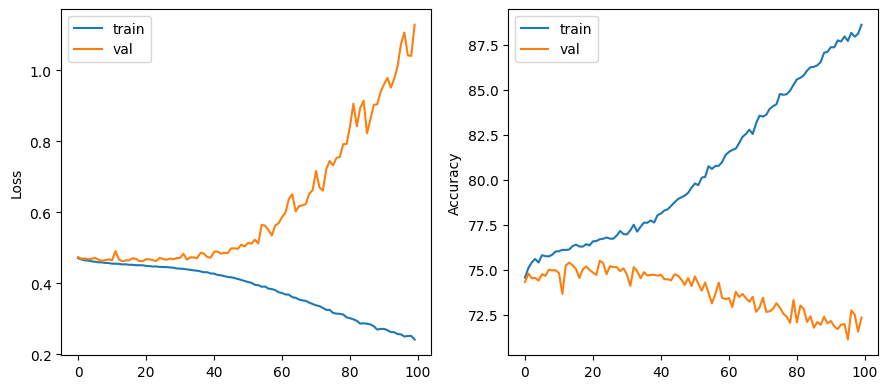

In [122]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9, 4))

ax1.plot(stats['train']['loss'], label='train')
ax1.plot(stats['val']['loss'], label='val')
ax1.set_ylabel('Loss')
ax1.legend()
ax2.plot(stats['train']['acc'], label='train')
ax2.plot(stats['val']['acc'], label='val')
ax2.set_ylabel('Accuracy')
ax2.legend()
fig.tight_layout()
fig.savefig('loss_acc.png')

In [112]:
test_loss, test_acc = test(smoke_model, test_loader, loss_fn)
test_loss, test_acc

(4.985274011979212, tensor(63.3954, device='cuda:0'))

In [113]:
predict = predict(smoke_model, torch.tensor(X_test.values).float().to(device))

In [114]:
 sum(predict) / len(predict)

tensor([0.7106], device='cuda:0')

In [115]:
st = pd.DataFrame(stats)

In [116]:
st.to_csv('stats_46,32,23,2,6_.csv')